# Task 2: Linear Regression — Gold Price Prediction

**Course:** Mining Massive Data Sets (504048)  
**Topic:** Predict gold prices in Vietnam using Linear Regression with CUR dimensionality reduction  
**Framework:** PySpark (Distributed Computation)

---

## Overview

| Step | Description |
|------|-------------|
| 1 | Load & preprocess gold price data (2009–2025) |
| 2 | Generate sliding-window feature vectors (15 lag days → label) |
| 3 | Split into Train / Test (70 / 30) |
| 4 | Apply CUR dimensionality reduction (15 → 5, step = 1) |
| 5 | Train and evaluate `LinearRegression` for each reduced dimension |
| 6 | Visualize training loss curves & RMSE twin-bar chart |

## 1. Setup — Install Dependencies & Initialize Spark

In [1]:
!pip install pyspark --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.regression import LinearRegression
from pyspark.mllib.linalg.distributed import RowMatrix
from pyspark.mllib.linalg import Vectors as MLLibVectors

# Initialize a Spark Session with sufficient driver memory for in-memory operations
spark = (
    SparkSession.builder
    .appName("GoldPricePrediction")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark Session is ready!")
print(f"Spark version: {spark.version}")

Spark Session is ready!
Spark version: 4.0.2


## 2. Data — Load, Preprocess & Feature Engineering

**Dataset:** `gold_prices.csv` — daily gold prices in Vietnam (Aug 2009 – Jan 2025)  
**Columns:** `Date`, `Buy Price`, `Sell Price`

**Feature construction strategy (sliding window):**
- **Features:** Buy prices of the 15 consecutive days *before* day `t` → `[price_lag_1, …, price_lag_15]`
- **Label:** Buy price on day `t`

In [3]:
# ── Load CSV ────────────────────────────────────────────────────────────────
FILE_PATH = "gold_prices.csv"
NUM_LAG_DAYS = 15          # window size (number of previous days used as features)
TRAIN_RATIO  = 0.7         # 70 % training, 30 % testing
RANDOM_SEED  = 42

df_raw = spark.read.csv(FILE_PATH, header=True, inferSchema=True)

# Parse dates and sort chronologically so lag windows are correct
df_sorted = df_raw.withColumn("Date", F.to_date(F.col("Date"))).orderBy("Date")

# ── Build lag features ──────────────────────────────────────────────────────
window_spec  = Window.orderBy("Date")
feature_cols = []

df_features = df_sorted
for lag in range(1, NUM_LAG_DAYS + 1):
    col_name    = f"price_lag_{lag}"
    df_features = df_features.withColumn(col_name, F.lag("Buy Price", lag).over(window_spec))
    feature_cols.append(col_name)

# Drop rows that have NaN lags (first NUM_LAG_DAYS rows)
df_clean = df_features.dropna()

# ── Assemble feature vector ─────────────────────────────────────────────────
assembler   = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_prepared = assembler.transform(df_clean)

# Keep only the columns needed downstream
df_final = df_prepared.select(
    "Date",
    "features",
    F.col("Buy Price").alias("label")
)

# ── Train / Test split (random, 7:3) ────────────────────────────────────────
train_df, test_df = df_final.randomSplit([TRAIN_RATIO, 1 - TRAIN_RATIO], seed=RANDOM_SEED)

# ── Data report ─────────────────────────────────────────────────────────────
print("=" * 40)
print("         DATA REPORT")
print("=" * 40)
print(f"Total rows in source file  : {df_raw.count():,}")
print(f"Valid samples (after lags) : {df_final.count():,}")
print(f"Training samples (70 %)    : {train_df.count():,}")
print(f"Test samples     (30 %)    : {test_df.count():,}")
print("=" * 40)

df_final.show(10, truncate=False)

         DATA REPORT
Total rows in source file  : 5,565
Valid samples (after lags) : 5,550
Training samples (70 %)    : 3,960
Test samples     (30 %)    : 1,590
+----------+-------------------------------------------------------------------------------------------+-----+
|Date      |features                                                                                   |label|
+----------+-------------------------------------------------------------------------------------------+-----+
|2009-08-16|[21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-17|[21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-18|[21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-19|[21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-20|[21.13,21.13,21.13,21.13,21.13,21.13,21.13,21.13,2

## 3. CUR Dimensionality Reduction

CUR decomposition selects a subset of *columns* (features) that best explain the variance in the data.  
We use the **leverage-score** approach: columns with the highest squared-norm in the right singular
vectors `V` are the most informative.

**Reduction schedule:** 15 → 14 → … → 5 (step = 1, 11 experiments in total)

In [4]:
class CURReducer:
    """
    CUR Column Selection via leverage scores.

    The top-k columns with the highest leverage scores (sum of squared
    entries in the right singular matrix V) are selected.  These columns
    form an informative low-dimensional representation of the data.

    Parameters
    ----------
    k : int
        Target number of features after reduction.
    """

    def __init__(self, k: int):
        self.k = k
        self.selected_indices: list[int] | None = None

    # ── Public API ──────────────────────────────────────────────────────────

    def fit(self, df):
        """
        Compute leverage scores on `df` and select the top-k column indices.

        Parameters
        ----------
        df : Spark DataFrame
            Must contain a 'features' column of dense ML vectors.

        Returns
        -------
        list[int]  Sorted list of selected column indices.
        """
        # Convert ML vectors → MLlib vectors required by RowMatrix
        rdd_mllib = df.select("features").rdd.map(
            lambda row: MLLibVectors.dense(row.features.toArray())
        )
        row_matrix = RowMatrix(rdd_mllib)

        # Truncated SVD (only V is needed; U computation is skipped for speed)
        svd = row_matrix.computeSVD(self.k, computeU=False)
        V   = svd.V.toArray()          # shape: (n_features, k)

        # Leverage score of each feature = sum of squared entries in its row of V
        leverage_scores = np.sum(np.square(V), axis=1)

        # Select the k features with the highest scores (sorted ascending → take tail)
        self.selected_indices = sorted(
            np.argsort(leverage_scores)[-self.k:].tolist()
        )

        print(f"[CUR k={self.k}] Selected feature indices: {self.selected_indices}")
        return self.selected_indices

    def transform(self, df):
        """
        Project `df` onto the columns selected during `fit`.

        Parameters
        ----------
        df : Spark DataFrame with a 'features' column.

        Returns
        -------
        Spark DataFrame with 'features' replaced by the reduced vector.
        """
        if self.selected_indices is None:
            raise RuntimeError("Call fit() before transform().")

        indices = self.selected_indices  # capture for closure

        @F.udf(VectorUDT())
        def _select_cols(vector):
            return Vectors.dense([float(vector[i]) for i in indices])

        return df.withColumn("features", _select_cols("features"))

    def fit_transform(self, train_df, target_df):
        """Convenience: fit on `train_df`, then transform `target_df`."""
        self.fit(train_df)
        return self.transform(target_df)

## 4. Experiment Runner

Each experiment:
1. Instantiates a `CURReducer` for a given `k`.
2. Fits on the training set and transforms both train & test sets.
3. Trains a `LinearRegression` model and records the objective history and RMSE.

In [5]:
class RegressionExperiment:
    """
    Encapsulates a single CUR + LinearRegression experiment.

    Parameters
    ----------
    k          : int   — target number of features after CUR reduction.
    max_iter   : int   — maximum training iterations for LinearRegression.
    solver     : str   — solver algorithm ('l-bfgs', 'normal', 'auto').
    """

    def __init__(self, k: int, max_iter: int = 50, solver: str = "l-bfgs"):
        self.k         = k
        self.max_iter  = max_iter
        self.solver    = solver
        self.model     = None
        self.results: dict  = {}
        self.loss_history: list = []

    # ── Run ─────────────────────────────────────────────────────────────────

    def run(self, train_df, test_df) -> tuple[dict, list]:
        """
        Execute the full pipeline: CUR → fit LR → evaluate.

        Returns
        -------
        results      : dict  with keys 'k', 'train_rmse', 'test_rmse'
        loss_history : list  of objective values per iteration
        """
        # Step 1 — Dimensionality reduction
        cur          = CURReducer(k=self.k)
        cur.fit(train_df)
        train_reduced = cur.transform(train_df)
        test_reduced  = cur.transform(test_df)

        # Step 2 — Train Linear Regression
        lr = LinearRegression(
            featuresCol="features",
            labelCol="label",
            maxIter=self.max_iter,
            solver=self.solver,
        )
        self.model = lr.fit(train_reduced)

        # Step 3 — Evaluate
        self.loss_history = list(self.model.summary.objectiveHistory)

        self.results = {
            "k"          : self.k,
            "train_rmse" : self.model.summary.rootMeanSquaredError,
            "test_rmse"  : self.model.evaluate(test_reduced).rootMeanSquaredError,
        }

        print(
            f"[k={self.k:>2}] "
            f"Train RMSE = {self.results['train_rmse']:,.2f}  "
            f"| Test RMSE = {self.results['test_rmse']:,.2f}"
        )
        return self.results, self.loss_history

## 5. Run All Experiments (k = 15 down to 5)

In [6]:
K_START = 15   # original number of features
K_END   = 5    # minimum target dimension
K_STEP  = 1    # reduce by 1 each time

all_results:       list[dict]      = []
all_loss_histories: dict[int, list] = {}

print("=" * 55)
print(f"  Running experiments: k = {K_START} → {K_END} (step = {K_STEP})")
print("=" * 55)

for k in range(K_START, K_END - 1, -K_STEP):
    print(f"\n>>> Experiment — reducing to k = {k}")
    exp = RegressionExperiment(k=k)
    res, history = exp.run(train_df, test_df)
    all_results.append(res)
    all_loss_histories[k] = history

print("\n" + "=" * 55)
print("  All experiments completed.")
print("=" * 55)

  Running experiments: k = 15 → 5 (step = 1)

>>> Experiment — reducing to k = 15
[CUR k=15] Selected feature indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
[k=15] Train RMSE = 0.31  | Test RMSE = 0.30

>>> Experiment — reducing to k = 14
[CUR k=14] Selected feature indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14]
[k=14] Train RMSE = 0.31  | Test RMSE = 0.30

>>> Experiment — reducing to k = 13
[CUR k=13] Selected feature indices: [0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 14]
[k=13] Train RMSE = 0.31  | Test RMSE = 0.30

>>> Experiment — reducing to k = 12
[CUR k=12] Selected feature indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14]
[k=12] Train RMSE = 0.31  | Test RMSE = 0.30

>>> Experiment — reducing to k = 11
[CUR k=11] Selected feature indices: [0, 1, 3, 4, 6, 7, 8, 9, 10, 11, 14]
[k=11] Train RMSE = 0.31  | Test RMSE = 0.30

>>> Experiment — reducing to k = 10
[CUR k=10] Selected feature indices: [0, 2, 3, 6, 8, 9, 10, 11, 13, 14]
[k=10] Train RMSE = 0.31  | Test

## 6. Results — New Feature Representations (Row Embeddings)

Demonstrate the row embeddings produced by CUR for the best k (5 dimensions).

In [7]:
# Re-apply CUR at k=5 to inspect the actual transformed feature vectors
best_k   = K_END
cur_best = CURReducer(k=best_k)
cur_best.fit(train_df)

train_embedded = cur_best.transform(train_df)
test_embedded  = cur_best.transform(test_df)

print(f"\n--- Row Embeddings (k={best_k}) — Training Set (first 5 rows) ---")
train_embedded.select("Date", "features", "label").show(5, truncate=False)

print(f"--- Row Embeddings (k={best_k}) — Test Set (first 5 rows) ---")
test_embedded.select("Date", "features", "label").show(5, truncate=False)

[CUR k=5] Selected feature indices: [0, 1, 3, 10, 14]

--- Row Embeddings (k=5) — Training Set (first 5 rows) ---
+----------+-------------------------------+-----+
|Date      |features                       |label|
+----------+-------------------------------+-----+
|2009-08-16|[21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-17|[21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-19|[21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-20|[21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-21|[21.13,21.13,21.13,21.13,21.13]|21.13|
+----------+-------------------------------+-----+
only showing top 5 rows
--- Row Embeddings (k=5) — Test Set (first 5 rows) ---
+----------+-------------------------------+-----+
|Date      |features                       |label|
+----------+-------------------------------+-----+
|2009-08-18|[21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-22|[21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-24|[21.13,21.13,21.13,21.13,21.13]|21.13|
|2009-08-25|[21.13,21.13,21.13,21.13,21.13

## 7. Visualization

### 7a. Training Loss Curves — all experiments in a single chart  
### 7b. Twin-Bar Chart — Train vs Test RMSE for each k

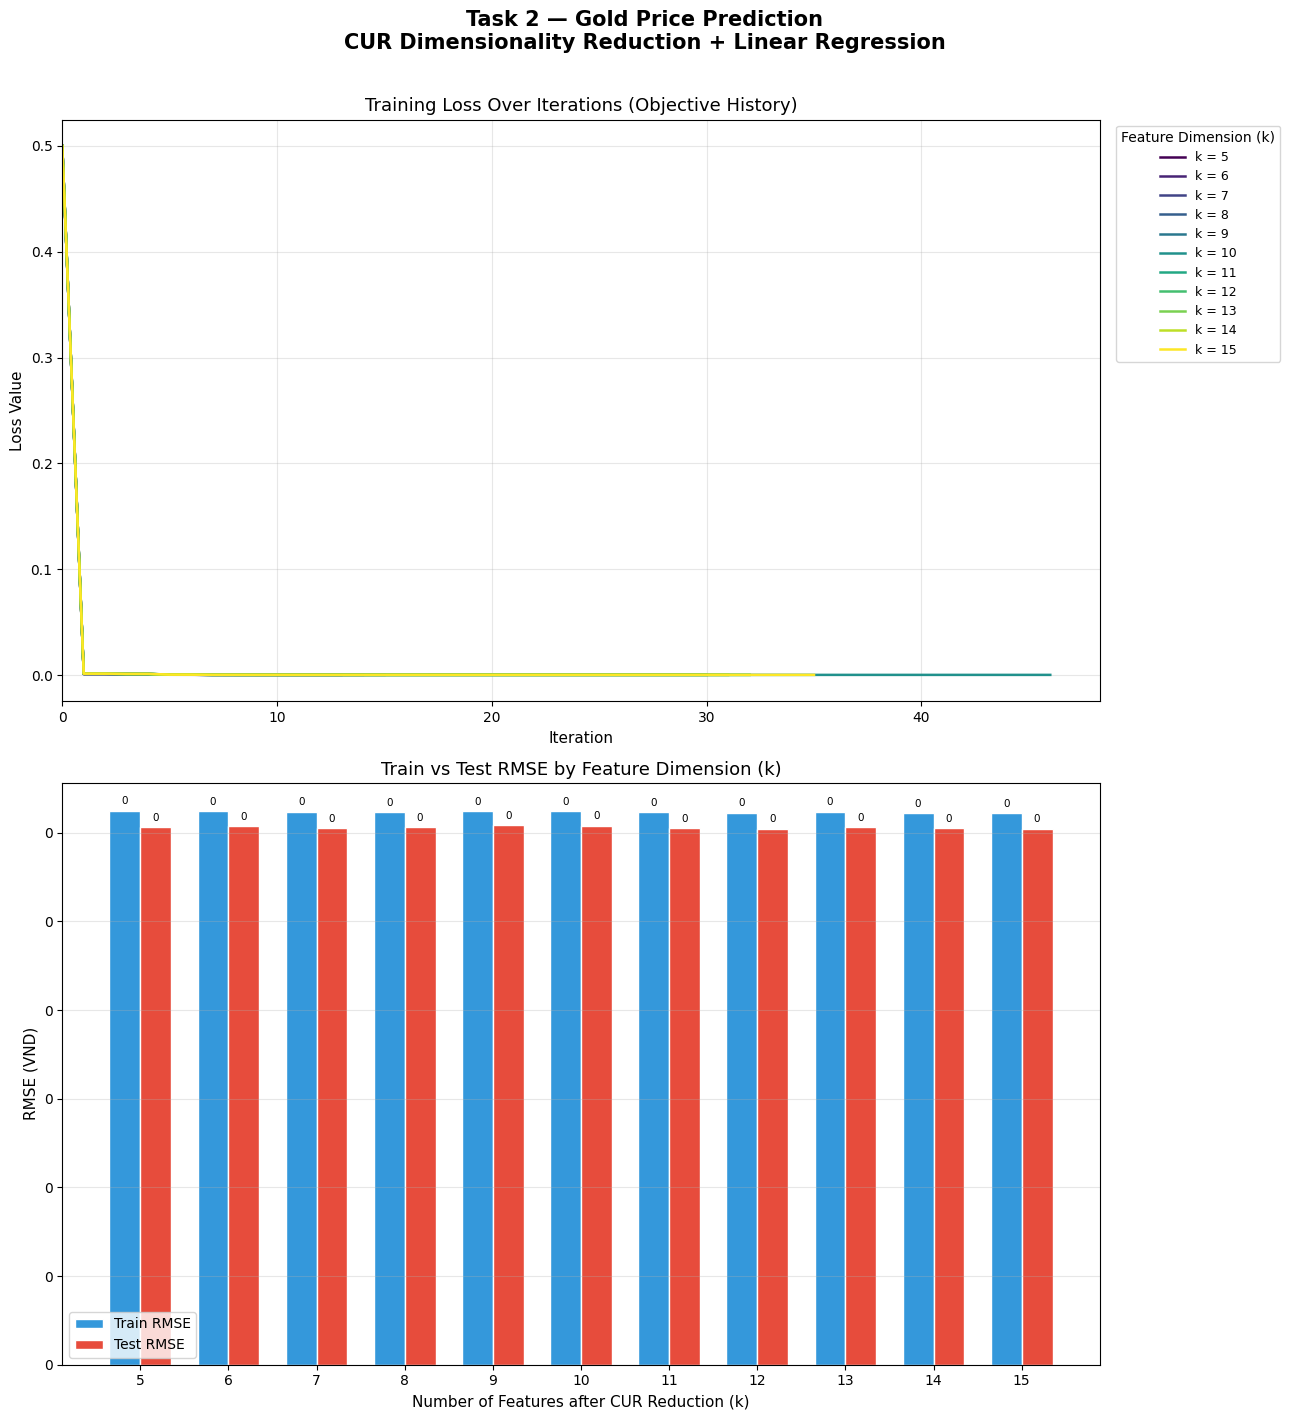

Figure saved to task02_results.png


In [8]:
# ── Prepare result arrays sorted by k (ascending) for the bar chart ─────────
sorted_results = sorted(all_results, key=lambda r: r["k"])
k_labels   = [str(r["k"])        for r in sorted_results]
train_rmse = [r["train_rmse"]    for r in sorted_results]
test_rmse  = [r["test_rmse"]     for r in sorted_results]

# ── Figure layout ────────────────────────────────────────────────────────────
fig, (ax_loss, ax_bar) = plt.subplots(2, 1, figsize=(13, 14))
fig.suptitle(
    "Task 2 — Gold Price Prediction\nCUR Dimensionality Reduction + Linear Regression",
    fontsize=15, fontweight="bold", y=1.01
)

# ── Plot 1: Training Loss Curves ─────────────────────────────────────────────
cmap   = plt.cm.viridis
k_vals = sorted(all_loss_histories.keys())
colors = cmap(np.linspace(0, 1, len(k_vals)))

for color, k in zip(colors, k_vals):
    history = all_loss_histories[k]
    ax_loss.plot(history, label=f"k = {k}", color=color, linewidth=1.8)

ax_loss.set_title("Training Loss Over Iterations (Objective History)", fontsize=13)
ax_loss.set_xlabel("Iteration",  fontsize=11)
ax_loss.set_ylabel("Loss Value", fontsize=11)
ax_loss.legend(
    title="Feature Dimension (k)",
    bbox_to_anchor=(1.01, 1), loc="upper left",
    fontsize=9, title_fontsize=10
)
ax_loss.grid(True, alpha=0.3)
ax_loss.set_xlim(left=0)

# ── Plot 2: Twin-Bar Chart — Train vs Test RMSE ──────────────────────────────
x     = np.arange(len(k_labels))
width = 0.35

bars_train = ax_bar.bar(
    x - width / 2, train_rmse, width,
    label="Train RMSE", color="#3498db", edgecolor="white"
)
bars_test = ax_bar.bar(
    x + width / 2, test_rmse, width,
    label="Test RMSE",  color="#e74c3c", edgecolor="white"
)

# Annotate bar tops
for bar in list(bars_train) + list(bars_test):
    height = bar.get_height()
    ax_bar.annotate(
        f"{height:,.0f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3), textcoords="offset points",
        ha="center", va="bottom", fontsize=7.5
    )

ax_bar.set_title("Train vs Test RMSE by Feature Dimension (k)", fontsize=13)
ax_bar.set_xlabel("Number of Features after CUR Reduction (k)", fontsize=11)
ax_bar.set_ylabel("RMSE (VND)", fontsize=11)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(k_labels)
ax_bar.legend(fontsize=10)
ax_bar.grid(axis="y", alpha=0.3)
ax_bar.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f"{val:,.0f}")
)

plt.tight_layout()
plt.savefig("task02_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to task02_results.png")

## 8. Summary Table

In [10]:
summary_df = pd.DataFrame(sorted_results)
summary_df["train_rmse"] = summary_df["train_rmse"].map("{:,.2f}".format)
summary_df["test_rmse"]  = summary_df["test_rmse"].map("{:,.2f}".format)
summary_df.columns       = ["Feature Dimension (k)", "Train RMSE (VND)", "Test RMSE (VND)"]

print("=" * 55)
print("         EXPERIMENT SUMMARY")
print("=" * 55)
print(summary_df.to_string(index=False))
print("=" * 55)

         EXPERIMENT SUMMARY
 Feature Dimension (k) Train RMSE (VND) Test RMSE (VND)
                     5             0.31            0.30
                     6             0.31            0.30
                     7             0.31            0.30
                     8             0.31            0.30
                     9             0.31            0.30
                    10             0.31            0.30
                    11             0.31            0.30
                    12             0.31            0.30
                    13             0.31            0.30
                    14             0.31            0.30
                    15             0.31            0.30


## 9. Cleanup — Stop Spark Session

In [11]:
spark.stop()
print("Spark Session stopped.")

Spark Session stopped.
